Generated hyperedges m = 2000


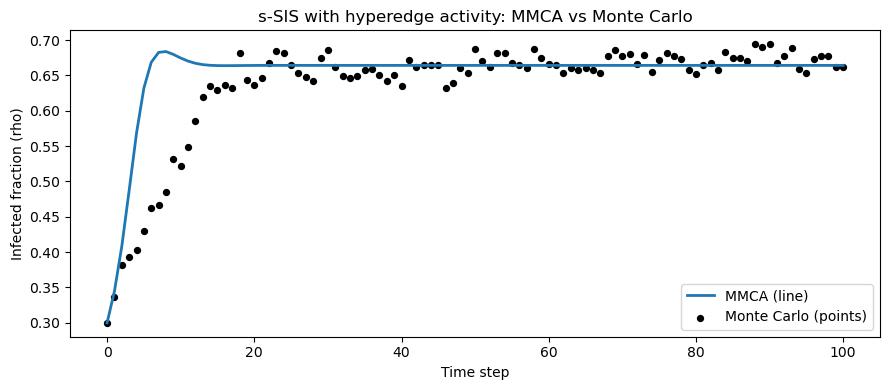

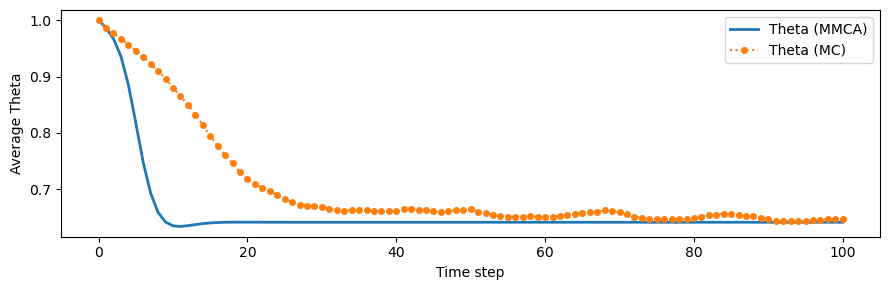

In [3]:
"""
HyperSISModel - 抽象封装的 3-uniform s-SIS 模型（包含 MMCA 与 Monte-Carlo 两种实现）
用法示例见脚本底部。
"""
import numpy as np
import random
import math
import matplotlib.pyplot as plt

def generate_hypergraph_H_n_m_3(n, kappa, seed=None, batch_size=3000):
    """生成随机 3-uniform hypergraph H(n,m,3)，去重。"""
    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)
    d = 3
    m = int(round(n * kappa / d))
    max_possible = math.comb(n, d)
    if m > max_possible:
        raise ValueError("m > C(n,3)")
    nodes = np.arange(n)
    edges_set = set()
    while len(edges_set) < m:
        tris = np.random.choice(nodes, size=(batch_size, d), replace=True)
        for i in range(tris.shape[0]):
            row = tris[i]
            if len(np.unique(row)) < d:
                row = np.random.choice(nodes, size=(d,), replace=False)
            tris[i] = np.sort(row)
        for row in tris:
            if len(edges_set) >= m:
                break
            edges_set.add(tuple(row.tolist()))
    hyperedges = np.array(list(edges_set), dtype=int)
    hyperedges.sort(axis=1)
    return hyperedges

class HyperSISModel:
    """
    3-uniform s-SIS model on a hypergraph with:
      - MMCA: run_mmca(...)
      - Monte-Carlo: run_mc(...), where infection trials use qi computed from p (EMA-smoothed)
    公共方法：
      - _compute_edge_products(p): 计算每条超边三个位置所需的“其他节点乘积”
      - compute_qi(p, Theta): 计算每个节点的 infection probability q_i（MMCA 表达式）
      - _update_theta_from_p(p, Theta): 使用 Phi_e = ∏ p_j 更新 Theta
    """
    def __init__(self, hyperedges, n):
        self.hyperedges = np.asarray(hyperedges, dtype=int)
        self.n = n
        self.m = self.hyperedges.shape[0]

        # 便于向量化的端点数组
        self.edge_i = self.hyperedges[:,0]
        self.edge_j = self.hyperedges[:,1]
        self.edge_k = self.hyperedges[:,2]

        # 预构建 node -> incident edges 映射 (列表 of (edge_idx, pos))
        self.node_edge_pos = [[] for _ in range(self.n)]
        for ei in range(self.m):
            a,b,c = self.hyperedges[ei]
            self.node_edge_pos[a].append((ei,0))
            self.node_edge_pos[b].append((ei,1))
            self.node_edge_pos[c].append((ei,2))

    # ---------- 公共工具方法 ----------
    def _compute_edge_products(self, p):
        """
        给定节点概率向量 p (长度 n)，返回每条超边在三个位置上用到的“其他节点乘积”：
          prod_pos0[ei] = p_j * p_k  (对应 edge_i 位置的“其他”)
          prod_pos1[ei] = p_i * p_k
          prod_pos2[ei] = p_i * p_j
        返回三个 numpy 数组 (prod_pos0, prod_pos1, prod_pos2) (长度 m)
        """
        p_i = p[self.edge_i]; p_j = p[self.edge_j]; p_k = p[self.edge_k]
        return (p_j * p_k, p_i * p_k, p_i * p_j)

    def compute_qi(self, p, Theta, beta_d):
        """
        计算每个节点 i 的感染概率 q_i：
          q_i = 1 - ∏_{e∈E_i} [1 - Θ_e * β_d * ∏_{j∈e\{i}} p_j]
        输入：
          p: 长度 n 的节点概率向量
          Theta: 长度 m 的超边活跃度向量
          beta_d: 传播参数
        返回 qi (长度 n)
        """
        prod_pos0, prod_pos1, prod_pos2 = self._compute_edge_products(p)
        qi = np.zeros(self.n, dtype=float)
        # 逐节点累乘 incident edges 中的项（node_edge_pos 已预构建）
        for node in range(self.n):
            prod_val = 1.0
            for (ei, pos) in self.node_edge_pos[node]:
                if pos == 0:
                    prod_oth = prod_pos0[ei]
                elif pos == 1:
                    prod_oth = prod_pos1[ei]
                else:
                    prod_oth = prod_pos2[ei]
                prod_val *= (1.0 - Theta[ei] * beta_d * prod_oth)
            qi[node] = 1.0 - prod_val
        return np.clip(qi, 0.0, 1.0)

    def _update_theta_from_p(self, p, Theta, eta, gamma):
        """
        使用 p 计算 Phi_e = ∏_{j∈e} p_j 并更新 Theta:
          Theta_e <- Theta_e * (1 - eta*Phi_e) + gamma*(1 - Theta_e)
        返回更新后的 Theta（修改并返回一个新数组）
        """
        p_i = p[self.edge_i]; p_j = p[self.edge_j]; p_k = p[self.edge_k]
        Phi = p_i * p_j * p_k
        Theta_new = Theta * (1.0 - eta * Phi) + gamma * (1.0 - Theta)
        return np.clip(Theta_new, 0.0, 1.0)

    # ---------- MMCA 实现 ----------
    def run_mmca(self, beta_d=0.3, mu=0.2, eta=1.0, gamma=0.05,
                 T=100, init_frac=0.01, verbose=False):
        """
        运行 MMCA 离散迭代，返回 (rho_ts, theta_ts)
        init_frac: 用于初始化每个 p_i(0) = init_frac
        """
        p = np.full(self.n, init_frac, dtype=float)
        Theta = np.ones(self.m, dtype=float)
        rho_ts = []
        theta_ts = []
        for t in range(T):
            rho_ts.append(p.mean())
            theta_ts.append(Theta.mean())
            # 计算 qi 需要的 Q = ∏(1 - Θ_e β ∏ p_others) 但我们直接用 compute_qi 计算 1 - Q
            # 这里我们需要 Q to compute p_next: p_next = (1-p)*(1-Q) + (1-mu)*p
            prod_pos0, prod_pos1, prod_pos2 = self._compute_edge_products(p)
            Q = np.ones(self.n, dtype=float)
            for node in range(self.n):
                prod_val = 1.0
                for (ei,pos) in self.node_edge_pos[node]:
                    if pos == 0:
                        prod_oth = prod_pos0[ei]
                    elif pos == 1:
                        prod_oth = prod_pos1[ei]
                    else:
                        prod_oth = prod_pos2[ei]
                    prod_val *= (1.0 - Theta[ei] * beta_d * prod_oth)
                Q[node] = prod_val

            p_next = (1.0 - p) * (1.0 - Q) + (1.0 - mu) * p
            # 更新 Theta（使用当前 p）
            Theta = self._update_theta_from_p(p, Theta, eta, gamma)
            p = p_next
            if verbose and (t % 20 == 0):
                print(f"[MMCA] t={t:3d}  rho={rho_ts[-1]:.4f}  ⟨Θ⟩={theta_ts[-1]:.4f}")

        rho_ts.append(p.mean()); theta_ts.append(Theta.mean())
        return np.array(rho_ts), np.array(theta_ts)

    # ---------- Monte-Carlo 实现 ----------
    def run_mc(self, beta_d=0.3, mu=0.2, eta=1.0, gamma=0.05,
               T=100, init_frac=0.1, seed=None, p_smooth=0.8, verbose=False):
        """
        运行 Monte-Carlo 仿真，但感染试验用 qi = compute_qi(p,Theta) 作为 Bernoulli 概率
        p_smooth: EMA 平滑系数（0 -> 无平滑，接近1 -> 强平滑/记忆）
        返回 (rho_ts, theta_ts)
        """
        if seed is not None:
            np.random.seed(seed); random.seed(seed)

        # 初始化二值状态
        states = np.zeros(self.n, dtype=int)
        initial_infected = max(1, int(round(init_frac * self.n)))
        init_nodes = np.random.choice(self.n, size=initial_infected, replace=False)
        states[init_nodes] = 1

        # 初始化 p（概率估计）和 Theta
        p = np.full(self.n, init_frac, dtype=float)
        Theta = np.ones(self.m, dtype=float)

        rho_ts = []
        theta_ts = []

        for t in range(T):
            rho_ts.append(states.mean()); theta_ts.append(Theta.mean())

            # 更新 p（EMA）
            if p_smooth == 0.0:
                p = states.astype(float)
            else:
                alpha = float(p_smooth)
                p = alpha * p + (1.0 - alpha) * states

            # 计算 qi 并用其进行感染试验
            qi = self.compute_qi(p, Theta, beta_d)

            # infection trials (for susceptible nodes)
            susceptible_idx = np.where(states == 0)[0]
            new_infections = set()
            for node in susceptible_idx:
                if np.random.rand() < qi[node]:
                    new_infections.add(int(node))

            # recovery trials
            infected_idx = np.where(states == 1)[0]
            if infected_idx.size > 0:
                recovered_mask = np.random.rand(infected_idx.size) < mu # [True, False, True]
                recovered_nodes = infected_idx[recovered_mask] # recovered_nodes = [1, 3, 4][[True, False, True]] → [1, 4]
            else:
                recovered_nodes = np.array([], dtype=int)

            # 同步更新：先恢复再感染
            next_states = states.copy()
            if recovered_nodes.size > 0:
                next_states[recovered_nodes] = 0
            for node in new_infections:
                if next_states[node] == 0:
                    next_states[node] = 1
            states = next_states

            # 更新 Theta（基于 p）
            Theta = self._update_theta_from_p(p, Theta, eta, gamma)

            if verbose and (t % 20 == 0):
                print(f"[MC] t={t:3d}  rho={rho_ts[-1]:.4f}  ⟨Θ⟩={theta_ts[-1]:.4f}")

        rho_ts.append(states.mean()); theta_ts.append(Theta.mean())
        return np.array(rho_ts), np.array(theta_ts)

# -------------------- 示例：如何使用 --------------------
if __name__ == "__main__":
    # 固定参数（你给出的）
    n = 1000
    kappa = 6.0
    beta = 0.3
    mu = 0.2
    T = 100
    init_frac = 0.3
    seed = 12345
    eta = 0.5
    gamma = 0.3
    p_smooth = 0.8

    # 生成超图
    hyperedges = generate_hypergraph_H_n_m_3(n=n, kappa=kappa, seed=seed, batch_size=3000)
    print("Generated hyperedges m =", hyperedges.shape[0])

    model = HyperSISModel(hyperedges, n)

    # 运行 MMCA（确定性）
    rho_mmca, theta_mmca = model.run_mmca(beta_d=beta, mu=mu, eta=eta, gamma=gamma,
                                         T=T, init_frac=init_frac, verbose=False)

    # 运行 Monte-Carlo（随机），使用 EMA 平滑 p
    rho_mc, theta_mc = model.run_mc(beta_d=beta, mu=mu, eta=eta, gamma=gamma,
                                    T=T, init_frac=init_frac, seed=seed, p_smooth=p_smooth, verbose=False)

    # 绘图比较
    ts = np.arange(len(rho_mc))
    plt.figure(figsize=(9,4))

    plt.plot(ts, rho_mmca, label='MMCA (line)', linewidth=2)

    plt.scatter(ts, rho_mc, label='Monte Carlo (points)', color='black', s=18)

    plt.xlabel("Time step")
    plt.ylabel("Infected fraction (rho)")
    plt.title("s-SIS with hyperedge activity: MMCA vs Monte Carlo")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(9,3))
    plt.plot(ts, theta_mmca, label='Theta (MMCA)', linewidth=2)
    plt.plot(ts, theta_mc, label='Theta (MC)', linestyle=':', marker='o', markersize=4)
    plt.xlabel("Time step") 
    plt.ylabel("Average Theta")
    plt.legend()
    plt.tight_layout() 
    plt.show()
